In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from xgcm import Grid

import sys
sys.path.append('../src/training-on-CM2.6/')
from helpers.train_rho_fluxes import *
from helpers.cm26 import read_datasets
from helpers.selectors import *

In [ ]:
from helpers.ann_tools import import_ANN
# Canonical NEUTRAL model (was sigma0 EXP0); see src/training-on-CM2.6/DENSITY_REFERENCE.md
ann_instance = import_ANN('/home/db194/scratch_db194/mom6/CM26_ML_models/FGR3/EXP_neutral_all4/model/ann_instance.nc')

In [ ]:
ds = read_datasets(factors=[4, 9, 12, 15], subfilter='subfilter-neutral')  # neutral data to match the neutral model

In [5]:
def compare_local(ds_name='test-9', zl=20):
    dds = ds[ds_name].select2d(zl=zl)
    
    true = dds.data
    prediction = dds.state.ANN_rho_inference(ann_instance, return_xarray=True)
    
    plt.figure(figsize=(8,7))
    compare(dds.nanvar(prediction['Fy_xarray'],0), 
        dds.nanvar(true['Fy'],0), 
        selector=select_globe,
        label_test='ANN prediction',
        label_control='CM2.6 truth')

Correlation: 0.9025909900665283
Relative Error: 0.47075918316841125
R2 =  0.8123175948858261
R2 max =  0.8139676451683044
Optinal scaling: 0.9569154977798462
Nans [test/control]: [55989, 55989]


<Figure size 800x700 with 0 Axes>

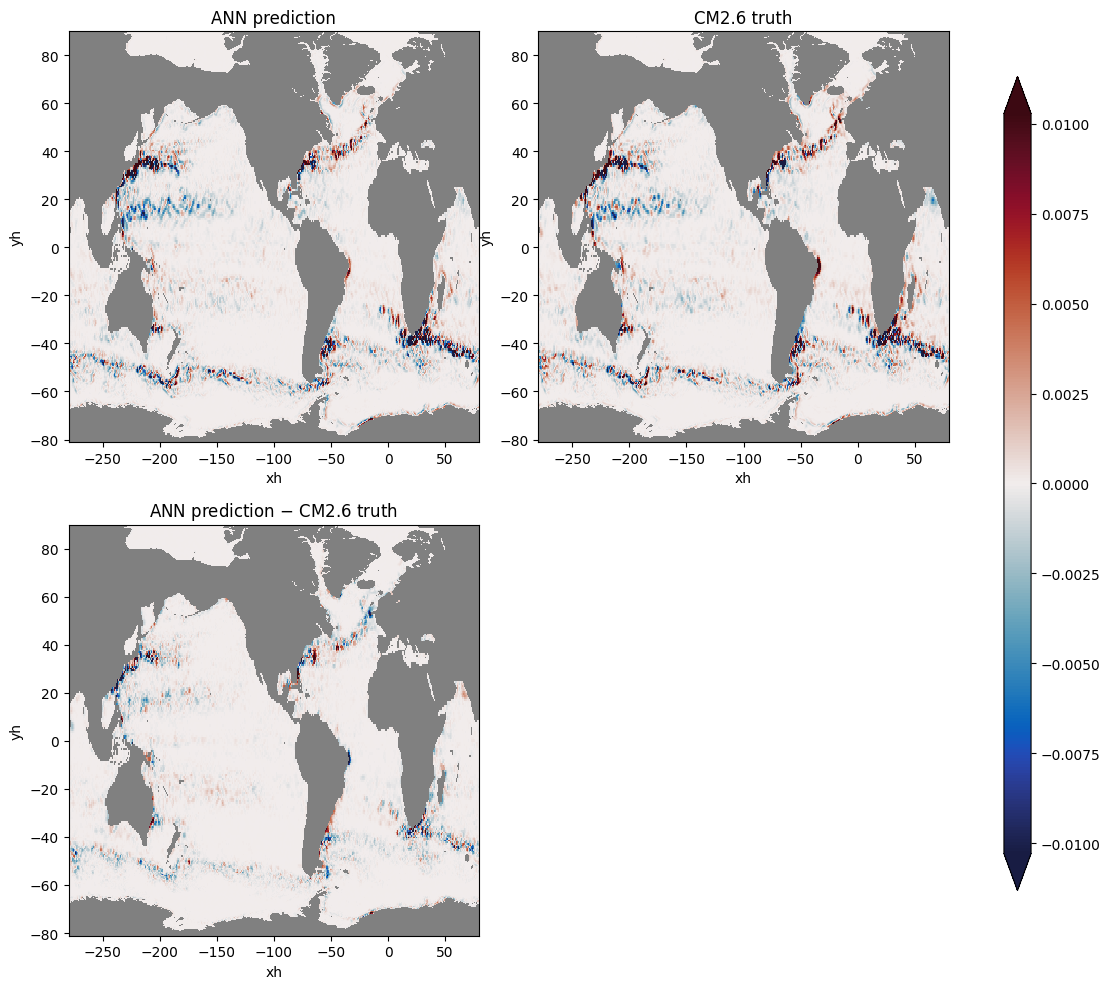

In [6]:
compare_local()

Correlation: 0.9580495357513428
Relative Error: 0.30707454681396484
R2 =  0.9166942313313484
R2 max =  0.9178571105003357
Optinal scaling: 0.9656293988227844
Nans [test/control]: [283896, 283896]


<Figure size 800x700 with 0 Axes>

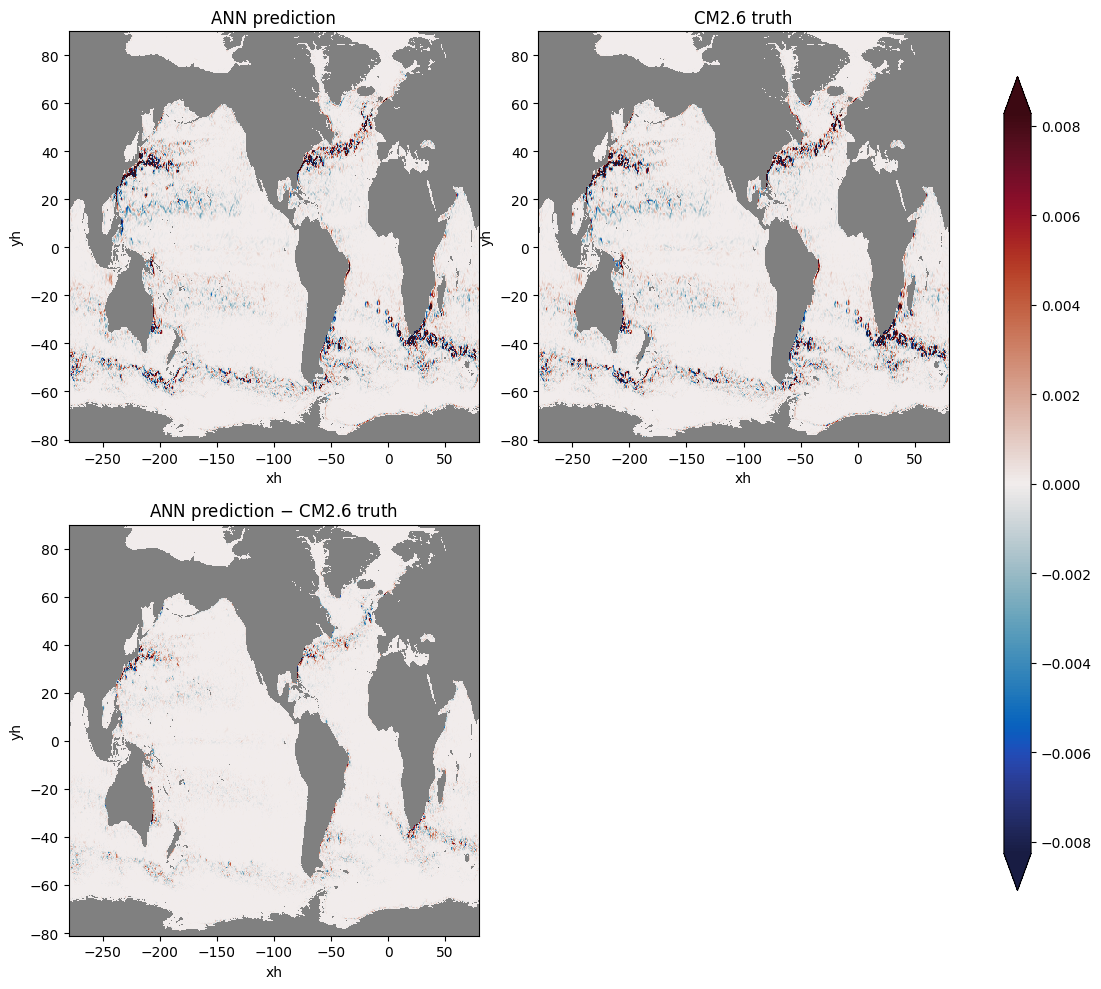

In [7]:
compare_local('test-4')

Correlation: 0.8797854781150818
Relative Error: 0.539863109588623
R2 =  0.7694457024335861
R2 max =  0.773406520485878
Optinal scaling: 0.9332163333892822
Nans [test/control]: [31522, 31522]


<Figure size 800x700 with 0 Axes>

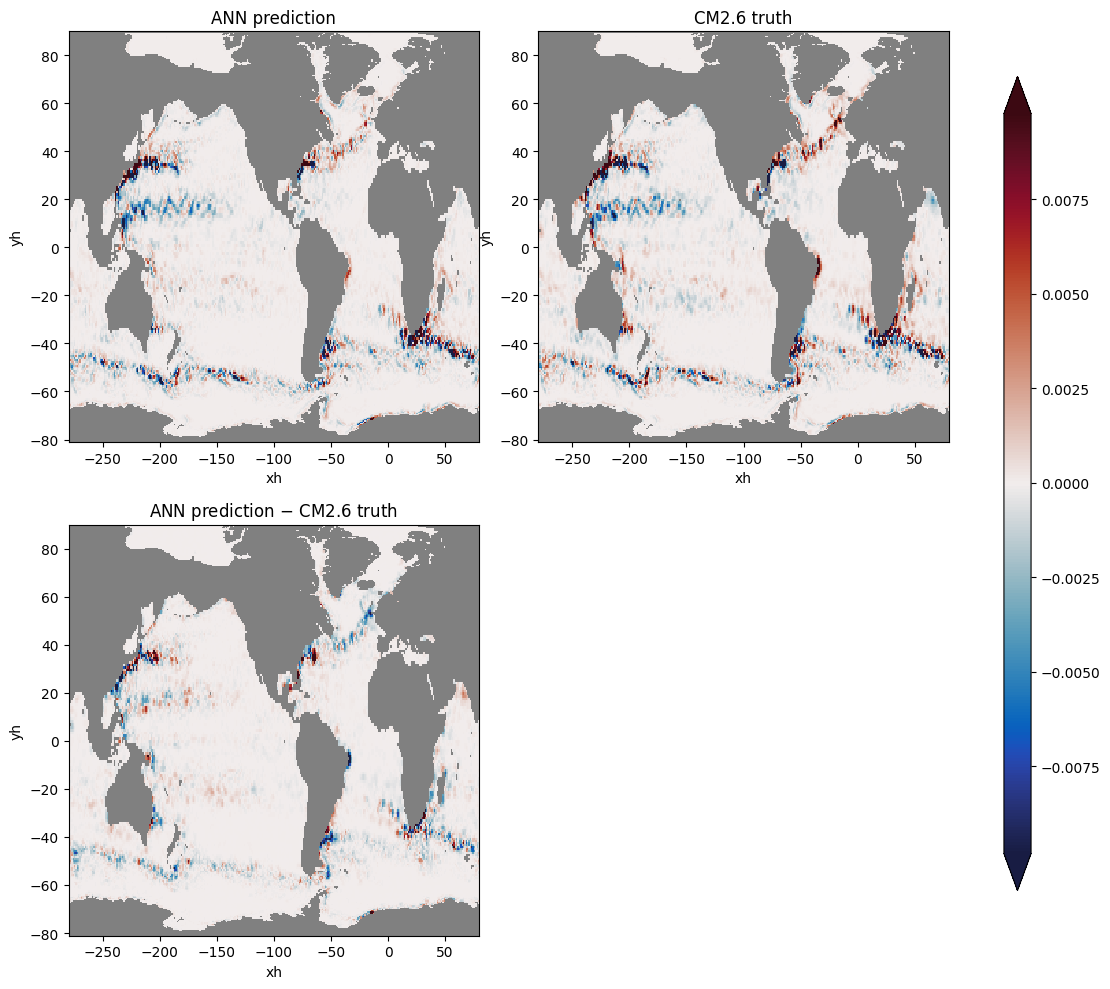

In [8]:
compare_local('test-12')

Correlation: 0.8582993745803833
Relative Error: 0.5804837346076965
R2 =  0.7359753549098969
R2 max =  0.7367582023143768
Optinal scaling: 1.0336949825286865
Nans [test/control]: [20219, 20219]


<Figure size 800x700 with 0 Axes>

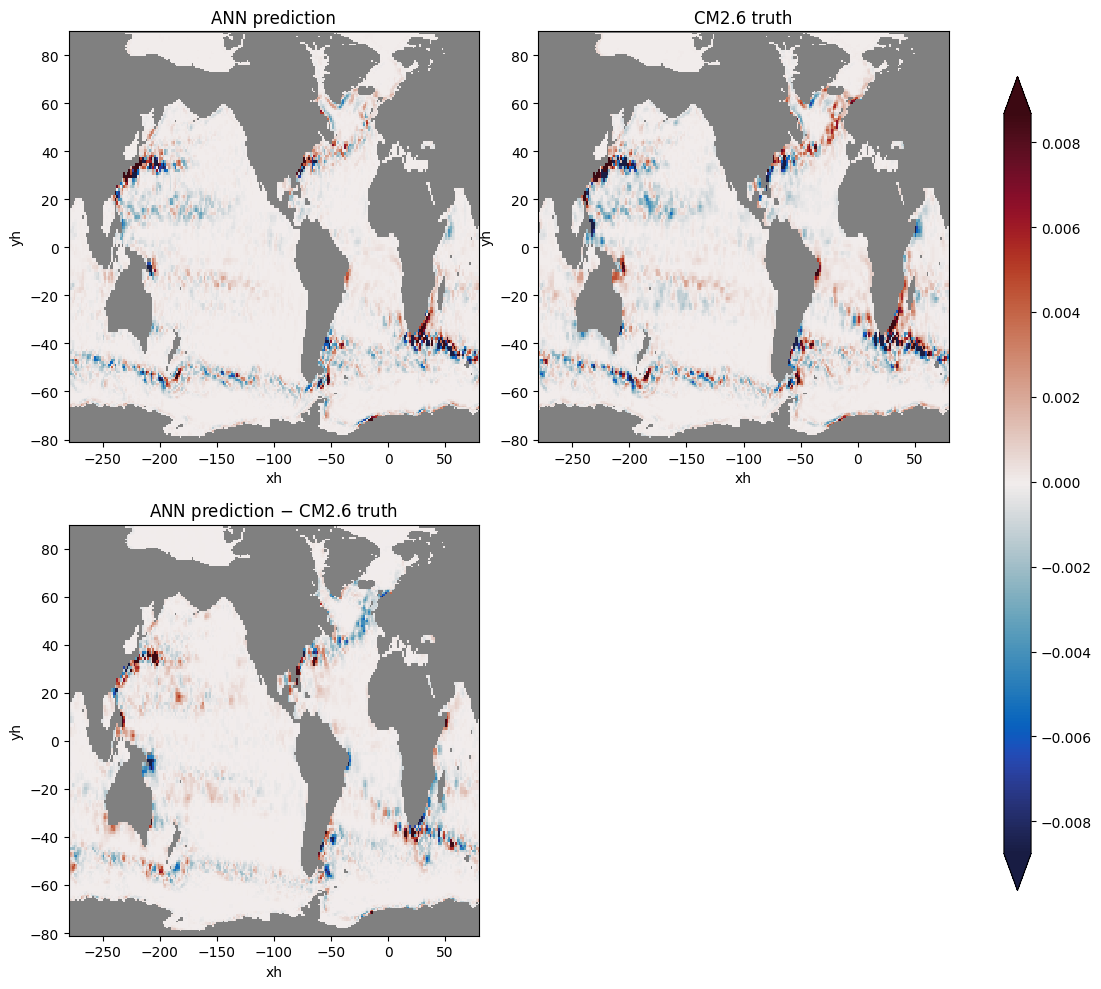

In [9]:
compare_local('test-15')

Correlation: 0.9047113060951233
Relative Error: 0.4475821256637573
R2 =  0.8144249022006989
R2 max =  0.8184309303760529
Optinal scaling: 0.934611976146698
Nans [test/control]: [59396, 59396]


array([[<Axes: title={'center': 'ANN prediction'}, xlabel='xh', ylabel='yh'>,
        <Axes: title={'center': 'CM2.6 truth'}, xlabel='xh', ylabel='yh'>],
       [<Axes: title={'center': 'ANN prediction $-$ CM2.6 truth'}, xlabel='xh', ylabel='yh'>,
        <Axes: >]], dtype=object)

<Figure size 800x700 with 0 Axes>

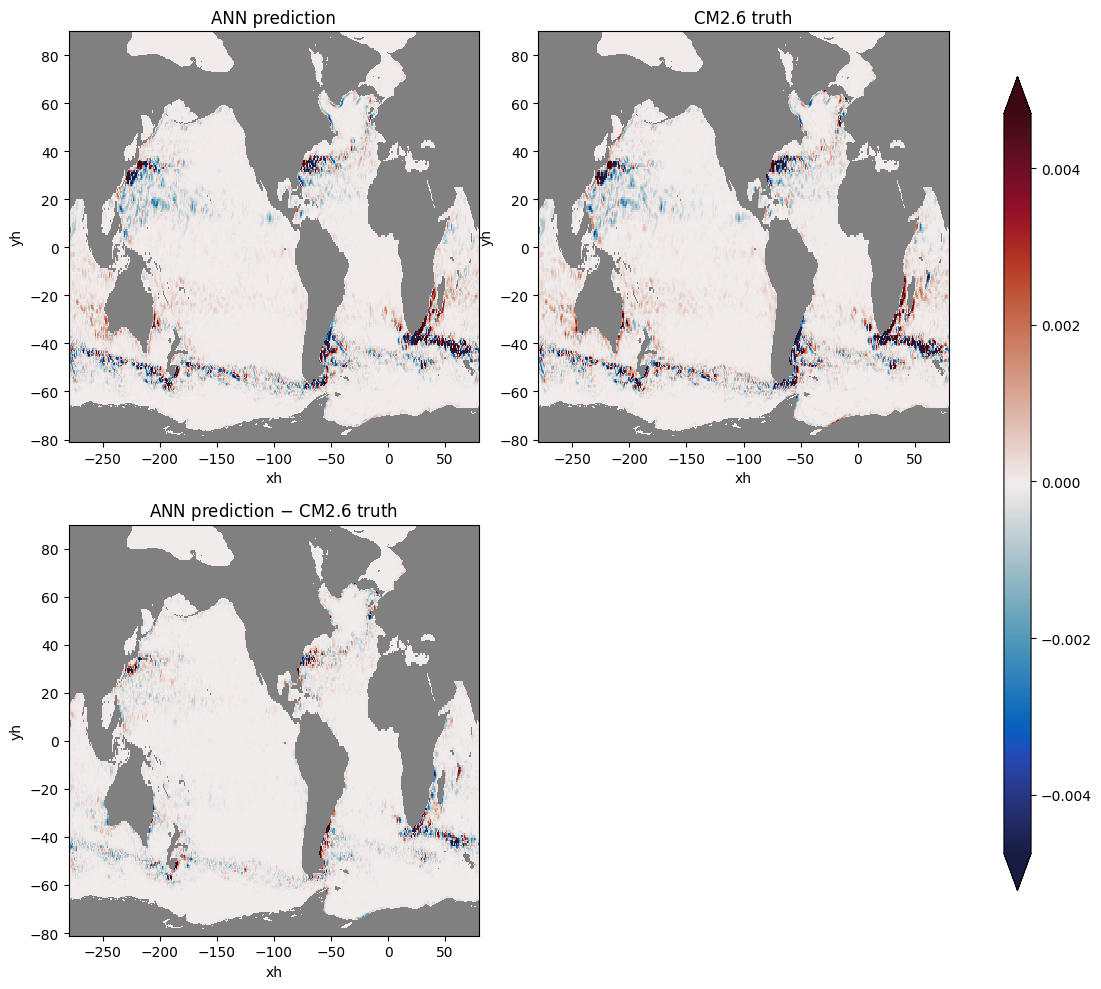

In [17]:
plt.figure(figsize=(8,7))
compare(dds.nanvar(prediction['Fy_xarray'],0), 
        dds.nanvar(dds.data.Fy,0), 
        selector=select_globe,
        label_test='ANN prediction',
        label_control='CM2.6 truth')

Correlation: 0.8346332311630249
Relative Error: 0.5618391633033752
R2 =  0.692151814699173
R2 max =  0.6977510452270508
Optinal scaling: 0.9177843332290649
Nans [test/control]: [2406, 2406]


array([[<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='xh', ylabel='yh'>,
        <Axes: >]], dtype=object)

<Figure size 800x700 with 0 Axes>

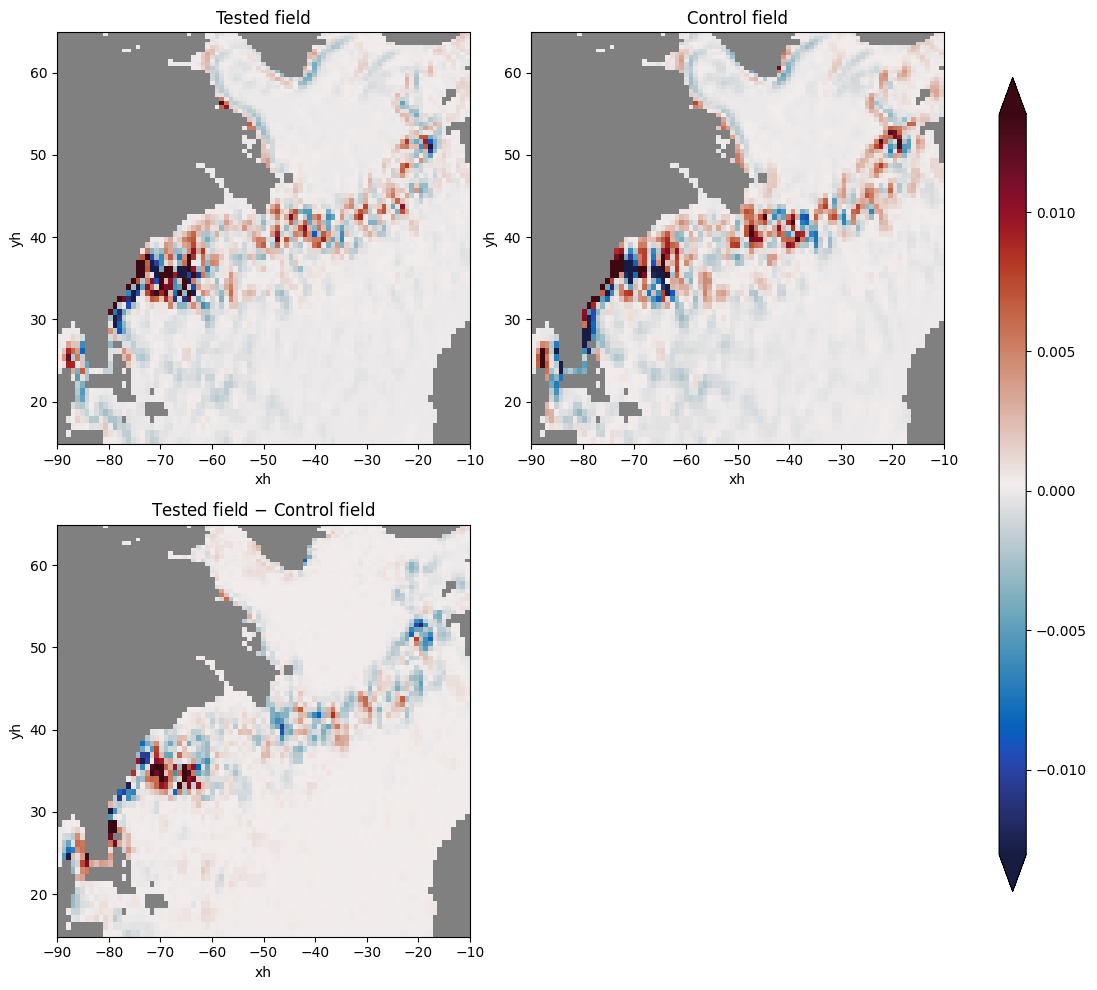

In [9]:
plt.figure(figsize=(8,7))
compare(dds.nanvar(prediction['Fy_xarray'],0), dds.nanvar(dds.data.Fy,0), 
selector=select_NA)

Correlation: 0.9268574714660645
Relative Error: 0.38351064920425415
R2 =  0.8576031029224396
R2 max =  0.8586501777172089
Optinal scaling: 0.9662580490112305
Nans [test/control]: [508, 508]


array([[<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='xh', ylabel='yh'>,
        <Axes: >]], dtype=object)

<Figure size 800x700 with 0 Axes>

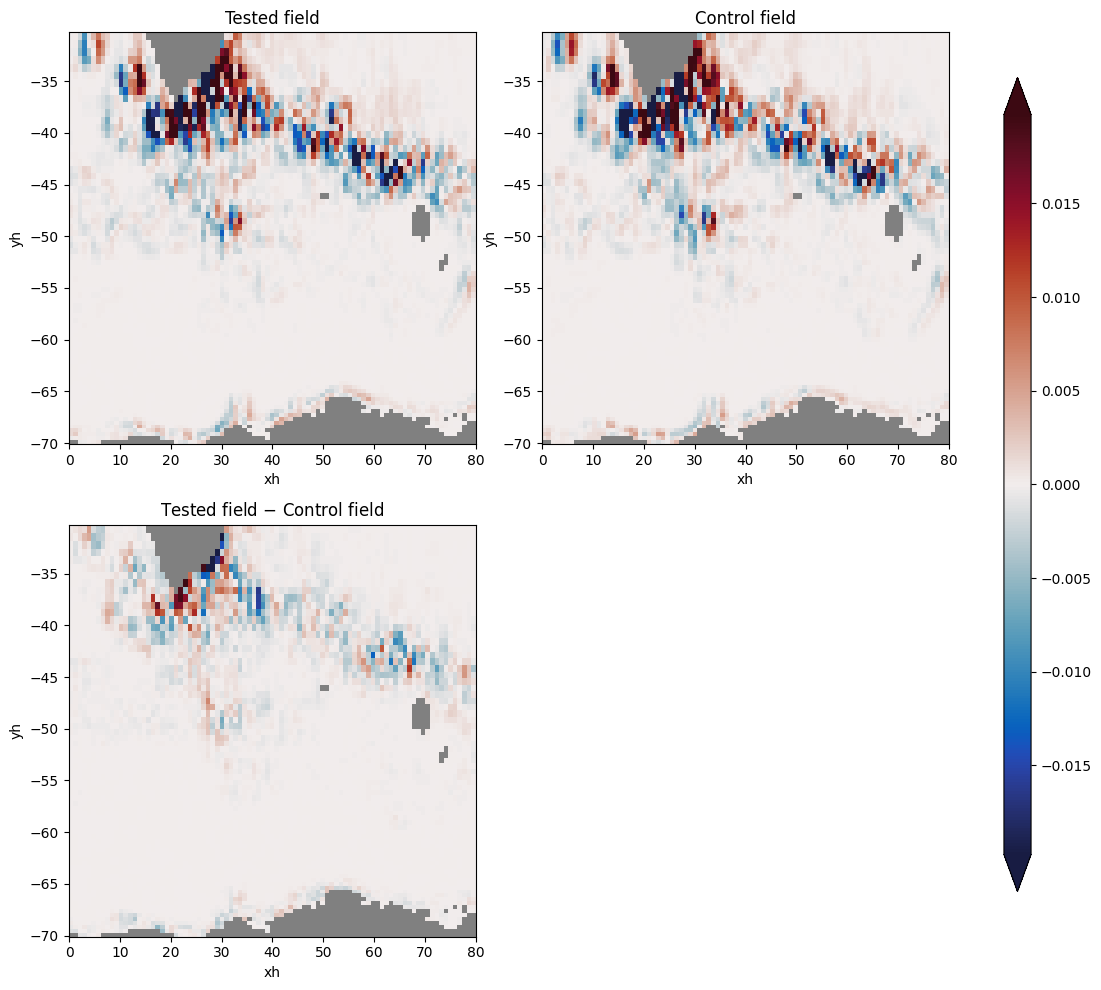

In [10]:
plt.figure(figsize=(8,7))
compare(dds.nanvar(prediction['Fy_xarray'],0), dds.nanvar(dds.data.Fy,0), 
selector=select_SO)

Correlation: 0.8346332311630249
Relative Error: 0.5618391633033752
R2 =  0.692151814699173
R2 max =  0.6977510452270508
Optinal scaling: 0.9177843332290649
Nans [test/control]: [2406, 2406]


array([[<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='xh', ylabel='yh'>,
        <Axes: >]], dtype=object)

<Figure size 800x700 with 0 Axes>

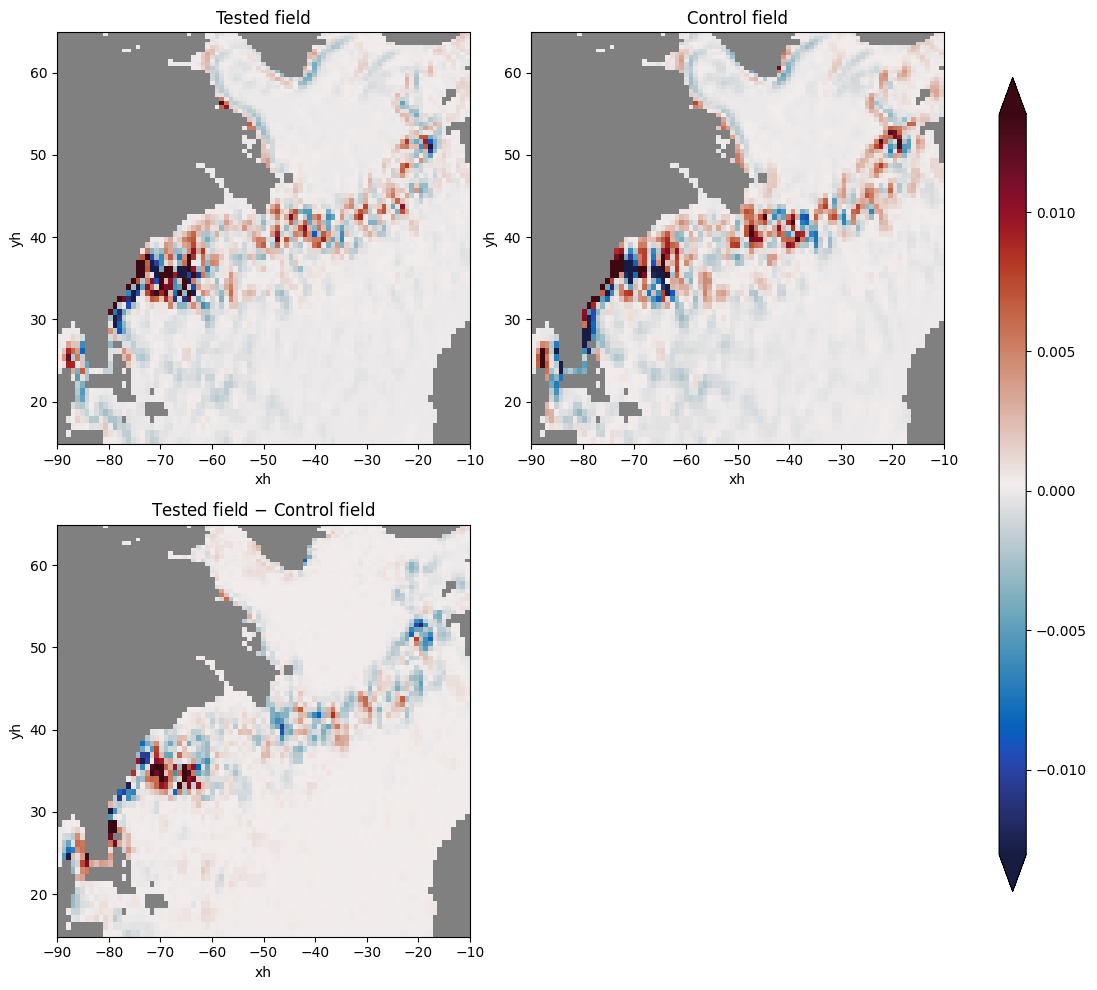

In [ ]:
plt.figure(figsize=(8,7))
compare(dds.nanvar(prediction['Fy_xarray'],0), dds.nanvar(dds.data.Fy,0), )

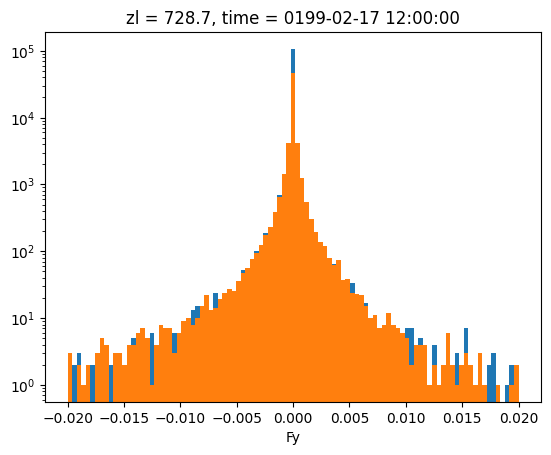

In [22]:
prediction['Fy_xarray'].plot.hist(bins=np.linspace(-2e-2,2e-2,100))
dds.nanvar(dds.data.Fy,0).plot.hist(bins=np.linspace(-2e-2,2e-2,100))
plt.yscale('log')

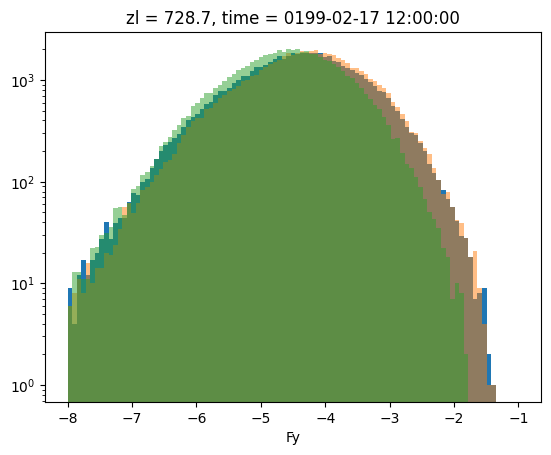

In [30]:
np.log10(np.abs(prediction['Fy_xarray'])).plot.hist(bins=np.linspace(-8,-1,100))
np.log10(np.abs(dds.data.Fy)).plot.hist(bins=np.linspace(-8,-1,100), alpha=0.5)
np.log10(np.abs(dds.data.Fy -   prediction['Fy_xarray'])).plot.hist(bins=np.linspace(-8,-1,100), alpha=0.5)
plt.yscale('log')

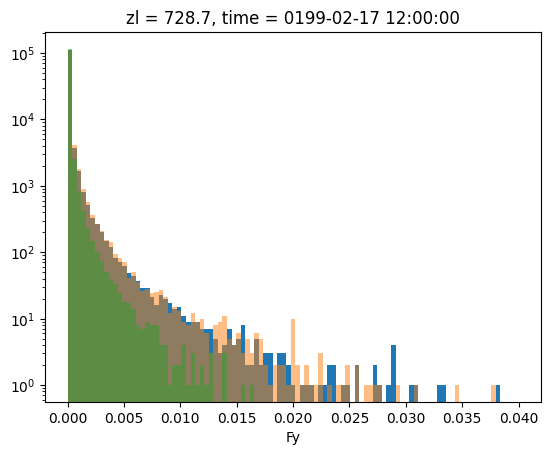

In [33]:
(np.abs(prediction['Fy_xarray'])).plot.hist(bins=np.linspace(0,4e-2,100))
(np.abs(dds.data.Fy)).plot.hist(bins=np.linspace(0,4e-2,100), alpha=0.5)
(np.abs(dds.data.Fy -   prediction['Fy_xarray'])).plot.hist(bins=np.linspace(0,4e-2,100), alpha=0.5)
plt.yscale('log')